# Analyze fitness effects

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

Read in data

In [2]:
# Read in fitness effects of amino-acid mutations
fitness_df = pd.read_csv('../results/aa_fitness_effects.csv', keep_default_na=False)
fitness_df = fitness_df[fitness_df['host'] == 'all']

# Read in data on average fitness effects of synonymous mutations at a given site
site_syn_fitness_df = pd.read_csv('../results/sitewise_synonymous_fitness_effects.csv', keep_default_na=False)
site_syn_fitness_df = site_syn_fitness_df[site_syn_fitness_df['host'] == 'all']

Plot the distribution of effects

expected or actual count >= 10
N = 43467


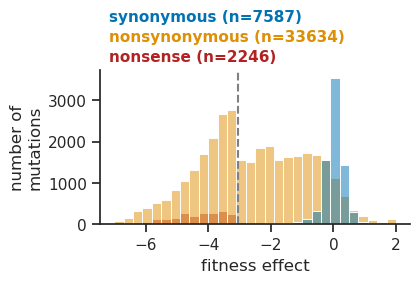

In [3]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
print(f'expected or actual count >= {count_threshold}\nN = {len(data)}')
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2, lower=-7)
plt.figure(figsize=(4,2))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=30,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors
)

# Annotate the number of mutations in each class
for (i, mut_class) in enumerate(['synonymous', 'nonsynonymous', 'nonsense']):
    count = (data['mut_class'] == mut_class).sum()
    median_fitness = data.loc[data['mut_class'] == mut_class, 'delta_fitness'].median()
    ax.text(
        #0.9, 0.9-i*0.13, f'{mut_class} (n={count})', ha='left', va='bottom',
        0.03, 1.3-i*0.13, f'{mut_class} (n={count})', ha='left', va='bottom',
        color=mut_class_colors[mut_class], fontsize=11, transform=ax.transAxes, fontweight='bold'
    )

ax.get_legend().remove()
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of\nmutations')
sns.despine()
plt.savefig('../results/figures/fitness_effect_dist.png', dpi=300, bbox_inches='tight')
plt.show()

Plot distributions of fitness effects as a function of gene.

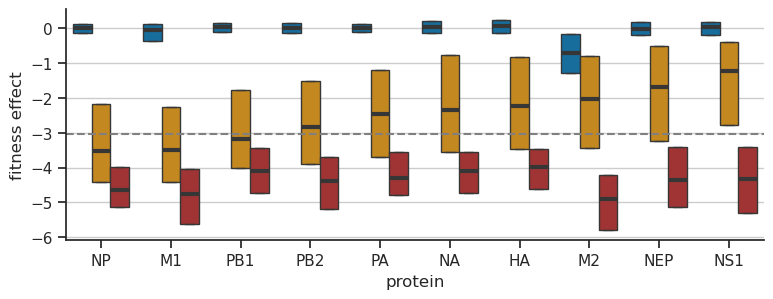

In [4]:
# Get data
count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .query('gene != "X-ORF"')
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[9,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
#plt.legend(bbox_to_anchor=(1,1))
plt.legend().remove()
plt.xlabel('protein')
plt.ylabel('fitness effect')
sns.despine()
plt.savefig('../results/figures/fitness_effect_dist_by_protein.png', dpi=300, bbox_inches='tight')
plt.show()

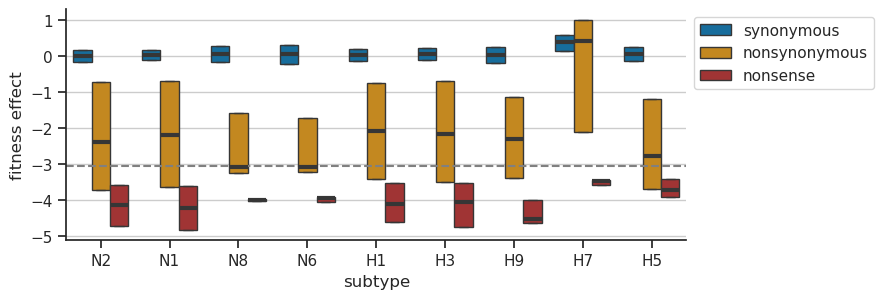

In [5]:
# Get data for HA/NA subtypes with at least 100 mutations with estimated fitness effects
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
subtype_counts = ha_na_data['subtype'].value_counts()
subtypes_to_include = subtype_counts[subtype_counts >= 100].index
ha_na_data = ha_na_data[ha_na_data['subtype'].isin(subtypes_to_include)]

# Plot distributions for different HA and NA subtypes
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

In [6]:
# Load packaging signal boundaries
packaging_signals = pd.read_csv('../data/packaging_signal_boundaries.csv', keep_default_na=False)

# Load splice-site boundaries (canonical M2 and NEP sites)
splice_sites = pd.read_csv('../data/splice_site_boundaries.csv', keep_default_na=False)

# Determine CDS length per segment from coding_sites.csv
# Use H1 for HA, N1 for NA, 'all' for internal segments
segment_subtypes = {
    'PB2': 'all', 'PB1': 'all', 'PA': 'all', 'HA': 'H1',
    'NP': 'all', 'NA': 'N1', 'MP': 'all', 'NS': 'all'
}
cds_lengths = {}
for segment, subtype in segment_subtypes.items():
    coding_sites = pd.read_csv(f'../results/{segment}/{subtype}/coding_sites.csv', keep_default_na=False)
    cds_lengths[segment] = coding_sites['site'].max()

# Helpers for drawing ORF rectangle tracks above MP and NS panels.
# (gene, fill color); listed bottom-to-top — first entry is the lower track.
orf_tracks = {
    'MP': [('M1', '#cccccc', 'M1'), ('M2', '#888888', 'M2')],
    'NS': [('NS1', '#cccccc', 'NS1'), ('NEP', '#888888', 'NEP')],
    # PA encodes a +1-frame X-ORF inside the PA CDS (Jagger et al. 2012);
    # display label is shortened to "X" so it fits inside the track.
    'PA': [('PA', '#cccccc', 'PA'), ('X-ORF', '#888888', 'X')],
}

def get_orf_exons(cs, gene):
    """Contiguous nt runs where ``gene`` is encoded; spliced ORFs yield multiple ranges."""
    cs = cs.sort_values('site').reset_index(drop=True)
    has_gene = cs['gene'].apply(lambda g: gene in g.split(';'))
    run_id = (has_gene != has_gene.shift()).cumsum()
    return [(int(g['site'].min()), int(g['site'].max()))
            for _, g in cs[has_gene].groupby(run_id)]

def draw_orf_track(ax, exons, y_low, y_high, color, label):
    for start, end in exons:
        ax.add_patch(plt.Rectangle(
            (start, y_low), end - start, y_high - y_low,
            transform=ax.get_xaxis_transform(),
            facecolor=color, edgecolor='black', linewidth=0.5,
            clip_on=False, zorder=5,
        ))
    longest = max(exons, key=lambda e: e[1] - e[0])
    ax.text(
        (longest[0] + longest[1]) / 2, (y_low + y_high) / 2, label,
        transform=ax.get_xaxis_transform(),
        ha='center', va='center', fontsize=7, clip_on=False, zorder=6,
    )

def shade_orf_overlap_regions(ax, segment, **kwargs):
    """Shade nt runs where two ORFs overlap (gene field contains ';')."""
    if segment not in orf_tracks:
        return
    seg_subtype = segment_subtypes[segment]
    cs = pd.read_csv(
        f'../results/{segment}/{seg_subtype}/coding_sites.csv',
        keep_default_na=False,
    ).sort_values('site').reset_index(drop=True)
    is_overlap = cs['gene'].str.contains(';')
    run_id = (is_overlap != is_overlap.shift()).cumsum()
    style = dict(alpha=0.2, color='gray', zorder=0, lw=0)
    style.update(kwargs)
    for _, run in cs[is_overlap].groupby(run_id):
        ax.axvspan(int(run['site'].min()), int(run['site'].max()), **style)

def draw_orf_tracks_above(ax, segment):
    """Draw per-gene exon rectangles above the data area for spliced segments."""
    if segment not in orf_tracks:
        return
    seg_subtype = segment_subtypes[segment]
    cs = pd.read_csv(
        f'../results/{segment}/{seg_subtype}/coding_sites.csv',
        keep_default_na=False,
    )
    track_h, track_gap, track_y0 = 0.07, 0.03, 1.07
    for j, (gene, color, label) in enumerate(orf_tracks[segment]):
        y_low = track_y0 + j * (track_h + track_gap)
        draw_orf_track(ax, get_orf_exons(cs, gene),
                       y_low, y_low + track_h, color, label)


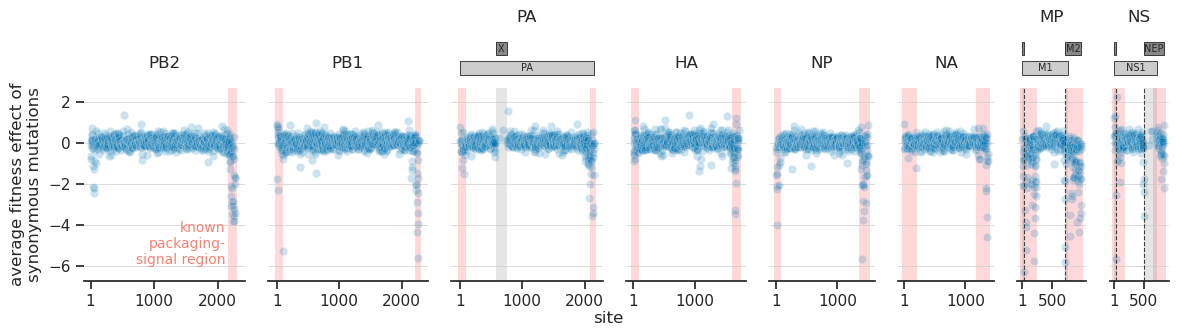

In [7]:
# Get data, subsetting HA to H1 and NA to N1
count_threshold = 10
syn_data = site_syn_fitness_df[site_syn_fitness_df['subtype'].isin(['all', 'H1', 'N1'])].copy()

# Get width ratios from CDS lengths
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = [cds_lengths[segment] for segment in segments]

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[14, 2.5],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    ax = axs[i]
    data = syn_data[syn_data['segment'] == segment]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=ax, alpha=0.2,
        color=mut_class_colors['synonymous']
    )

    # Add shaded packaging signal regions
    cds_len = cds_lengths[segment]
    for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
        if row['nt'] == 0:
            continue
        if row['end'] == '3prime_vRNA':
            x_start, x_end = 1, row['nt']
        else:  # 5prime_vRNA
            x_start, x_end = cds_len - row['nt'] + 1, cds_len
        # increase shaded region to mostly overlap with dots in region
        buffer = 30
        x_start -= buffer
        x_end += buffer
        ax.axvspan(x_start, x_end, alpha=0.15, color='red', zorder=0, lw=0)

    # Mark canonical splice sites (MP: M2; NS: NEP) with dashed vertical lines.
    # Gene structure (5'SS/3'SS positions, exon ranges) is now shown by the
    # ORF rectangle tracks above the plot, so the text labels are dropped.
    for _, row in splice_sites[splice_sites['segment'] == segment].iterrows():
        ax.axvline(row['position'], linestyle='--', color='0.25', linewidth=0.8, zorder=1)

    # Shade nt regions where two ORFs overlap (M1/M2 on MP; NS1/NEP on NS),
    # then draw ORF exon tracks above the plot.
    shade_orf_overlap_regions(ax, segment)
    draw_orf_tracks_above(ax, segment)

    # Annotate leftmost plot with packaging signal legend
    if i == 0:
        ax.text(0.88, 0.07, 'known\npackaging-\nsignal region', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=10, color='salmon')

    ax.grid(axis='y', which='both', lw=0.5)
    title_y = 1.30 if segment in orf_tracks else 1.06
    ax.set_title(segment, y=title_y)
    ax.set(xlabel='')
    if i > 0:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    if data['site'].max() < 1000:
        ax.set_xticks([1, 500])
    elif data['site'].max() < 2000:
        ax.set_xticks([1, 1000])
    else:
        ax.set_xticks([1, 1000, 2000])
    sns.despine(left=True, ax=ax)

axs[0].set(ylabel='average fitness effect of\nsynonymous mutations')
fig.text(0.5, -0.06, 'site', ha='center')
plt.savefig('../results/figures/fitness_effect_syn.png', dpi=300, bbox_inches='tight')
plt.show()

Zoom in on the ends of a specific segment.

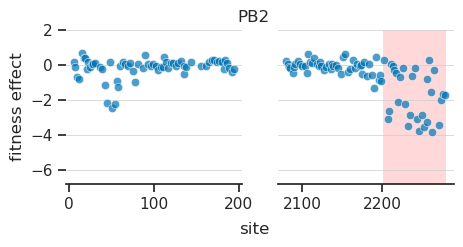

In [8]:
segment = 'PB2'
data = syn_data[(syn_data['segment'] == segment)]
cds_len = cds_lengths[segment]

left_site_range = (0, 200)
right_site_range = (data['site'].max()-200, data['site'].max()+1)
(fig, axs) = plt.subplots(ncols=2, sharey=True, figsize=[5,2])

left_data = data[data['site'].between(*left_site_range)]
right_data = data[data['site'].between(*right_site_range)]
sns.scatterplot(x='site', y='delta_fitness', data=left_data, alpha=0.7, ax=axs[0])
sns.scatterplot(x='site', y='delta_fitness', data=right_data, alpha=0.7, ax=axs[1])

# Shade 3'-vRNA signal on left plot, 5'-vRNA signal on right plot
for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
    if row['nt'] == 0:
        continue
    if row['end'] == '3prime_vRNA':
        axs[0].axvspan(1, row['nt'], alpha=0.15, color='red', zorder=0, lw=0)
    else:  # 5prime_vRNA
        x_start = cds_len - row['nt'] + 1
        axs[1].axvspan(x_start, cds_len, alpha=0.15, color='red', zorder=0, lw=0)

axs[0].grid(axis='y', which='both', lw=0.5)
axs[1].grid(axis='y', which='both', lw=0.5)

axs[0].set(ylabel='fitness effect', xlabel='', ylim=[-6.8,2])
axs[1].set(xlabel='')
plt.figtext(0.5, -0.14, 'site', ha='center')
plt.suptitle(segment, fontsize=12)

sns.despine(left=True, ax=axs[0])
axs[1].tick_params(axis='y', which='both', left=False, labelleft=False)
sns.despine(left=True, ax=axs[1])

plt.show()

Zoom in on the MP segment.

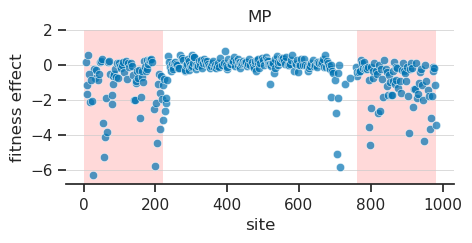

In [9]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
cds_len = cds_lengths[segment]

plt.figure(figsize=[5,2])
ax = plt.gca()
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.7, ax=ax)

# Add shaded packaging signal regions
for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
    if row['nt'] == 0:
        continue
    if row['end'] == '3prime_vRNA':
        x_start, x_end = 1, row['nt']
    else:  # 5prime_vRNA
        x_start, x_end = cds_len - row['nt'] + 1, cds_len
    ax.axvspan(x_start, x_end, alpha=0.15, color='red', zorder=0, lw=0)

plt.grid(axis='y', which='both', lw=0.5)
plt.ylim([-6.8,2])
plt.ylabel('fitness effect')
plt.title(segment)
sns.despine(left=True)
plt.show()

## Compare estimated fitness effects to experimentally measured DMS data

Read in data on HA.

In [10]:
# Get fitness data
count_threshold_dms_comparison = 25
ha_fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
ha_fitness_data['codon_site'] = ha_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
ha_dms_data = pd.read_csv('../results/dms_data/Yu_HA/processed_dms_data.csv')
ha_dms_data = (
    ha_dms_data
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(ha_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(ha_dms_data))
print('N sites with data:', ha_dms_data['codon_site'].nunique())
ha_dms_data.head()

N muts with data: 1411
N sites with data: 503


,site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,n_nt_changes,codon_site,reference_site,sequential_wt,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,Q,K,0.04918,-0.1115,0.001008,1,1,17,1,Q,all,H3,HA,HA,Q17K,nonsynonymous,53,44.831901,0.165671
1,1,Q,R,-0.19230,-0.8861,0.012610,1,1,17,1,Q,all,H3,HA,HA,Q17R,nonsynonymous,19,45.407005,-0.856203
2,2,K,E,-0.06889,-0.3198,0.050210,2,1,18,2,K,all,H3,HA,HA,K18E,nonsynonymous,73,75.776060,-0.037074
3,2,K,R,-0.10240,-0.6128,0.060580,2,1,18,2,K,all,H3,HA,HA,K18R,nonsynonymous,64,75.736828,-0.167179
6,3,I,V,-0.05354,-0.4621,0.012070,3,1,19,3,I,all,H3,HA,HA,I19V,nonsynonymous,57,70.324645,-0.208422


Read in data for NP.

In [11]:
# Get fitness data
np_fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
np_fitness_data['codon_site'] = np_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(np_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(np_dms_data))
print('N sites with data:', np_dms_data['codon_site'].nunique())
np_dms_data

N muts with data: 2098
N sites with data: 487


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
601,1,M,I,0.023434,0.391903,-2.816809,all,all,NP,NP,M1I,nonsynonymous,0,381.262739,-6.637946
1674,1,M,T,0.032492,0.391903,-2.490014,all,all,NP,NP,M1T,nonsynonymous,0,131.822930,-5.578393
761,1,M,K,0.038531,0.391903,-2.319554,all,all,NP,NP,M1K,nonsynonymous,0,42.552520,-4.455568
1369,1,M,R,0.028061,0.391903,-2.636616,all,all,NP,NP,M1R,nonsynonymous,0,27.757095,-4.034492
199,2,A,E,0.015231,0.753436,-3.901298,all,all,NP,NP,A2E,nonsynonymous,4,211.922017,-3.854498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1826,498,N,T,0.063578,0.088315,-0.328635,all,all,NP,NP,N498T,nonsynonymous,3,29.628881,-2.152721
2097,498,N,Y,0.011276,0.088315,-2.058196,all,all,NP,NP,N498Y,nonsynonymous,5,28.753479,-1.671250
923,498,N,K,0.276824,0.088315,1.142474,all,all,NP,NP,N498K,nonsynonymous,12,48.342175,-1.362866
760,498,N,I,0.073817,0.088315,-0.179316,all,all,NP,NP,N498I,nonsynonymous,17,33.177487,-0.654629


Read in data for PB2.

In [12]:
# Get fitness data
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
        'log2effectA549': 'dms_effect'
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb2_dms_data))
print('N sites with data:', pb2_dms_data['codon_site'].nunique())
pb2_dms_data.head()

N muts with data: 2909
N sites with data: 757


,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,...,Experimentally adaptive in,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
869,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,...,NaN,all,all,PB2,PB2,M1I,nonsynonymous,0,298.298144,-6.392915
2416,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,...,NaN,all,all,PB2,PB2,M1T,nonsynonymous,0,114.901961,-5.441569
1110,1,M,K,0.045065,0.042917,-4.471848,-4.542299,0.091968,0.118499,-3.442719,...,NaN,all,all,PB2,PB2,M1K,nonsynonymous,0,32.316545,-4.184080
1111,2,E,K,0.023902,0.043219,-5.386741,-4.532198,0.129111,0.277256,-2.953314,...,NaN,all,all,PB2,PB2,E2K,nonsynonymous,11,414.839914,-3.586750
573,2,E,G,0.028171,0.012344,-5.149633,-6.340091,0.152174,0.079186,-2.716206,...,NaN,all,all,PB2,PB2,E2G,nonsynonymous,12,258.913687,-3.032695


Read in data for NA.

In [13]:
# Get fitness data
na_fitness_data = fitness_df[
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['gene'] == 'NA') &
    (fitness_df['subtype'] == 'N1')
].copy()
na_fitness_data['codon_site'] = na_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
na_dms_data = (
    pd.read_csv('../results/dms_data/Wang_NA/processed_dms_data.csv')
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(na_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(na_dms_data))
print('N sites with data:', na_dms_data['codon_site'].nunique())
na_dms_data

N muts with data: 967
N sites with data: 345


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,7,I,M,7,-1.468916,all,N1,NA,NA,I7M,nonsynonymous,24,141.374715,-1.756271
1,8,I,L,8,-2.304362,all,N1,NA,NA,I8L,nonsynonymous,13,36.702968,-1.013699
2,8,I,V,8,-0.997490,all,N1,NA,NA,I8V,nonsynonymous,20,110.379358,-1.688018
3,8,I,T,8,-0.425550,all,N1,NA,NA,I8T,nonsynonymous,91,159.921616,-0.561466
4,8,I,M,8,-0.949175,all,N1,NA,NA,I8M,nonsynonymous,45,129.731548,-1.051602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,406,F,S,407,-2.372462,all,N1,NA,NA,F407S,nonsynonymous,3,157.545561,-3.810120
963,406,F,L,407,-2.546067,all,N1,NA,NA,F407L,nonsynonymous,4,196.597981,-3.779624
964,407,W,R,408,-2.351493,all,N1,NA,NA,W408R,nonsynonymous,1,97.536860,-4.179878
965,407,W,R,408,-4.840724,all,N1,NA,NA,W408R,nonsynonymous,1,97.536860,-4.179878


Read in data for PB1.

In [14]:
# Get fitness data
pb1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
pb1_fitness_data['codon_site'] = pb1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
pb1_dms_data = (
    pd.read_csv('../results/dms_data/Li_PB1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(pb1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb1_dms_data))
print('N sites with data:', pb1_dms_data['codon_site'].nunique())
pb1_dms_data.head()

N muts with data: 1320
N sites with data: 632


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,M,I,1,-0.859333,all,all,PB1,PB1,M1I,nonsynonymous,0,242.872620,-6.187741
1,1,M,K,1,-0.511153,all,all,PB1,PB1,M1K,nonsynonymous,0,26.107397,-3.974336
2,2,D,N,2,-0.940369,all,all,PB1,PB1,D2N,nonsynonymous,13,346.088936,-3.245450
3,2,D,E,2,-0.778942,all,all,PB1,PB1,D2E,nonsynonymous,4,46.192796,-2.339513
4,2,D,G,2,-0.755760,all,all,PB1,PB1,D2G,nonsynonymous,7,241.401721,-3.473629


Read in data for M1.

In [15]:
# Get fitness data
m1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'M1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
m1_fitness_data['codon_site'] = m1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
m1_dms_data = (
    pd.read_csv('../results/dms_data/Hom_M1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(m1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(m1_dms_data))
print('N sites with data:', m1_dms_data['codon_site'].nunique())
m1_dms_data.head()

N muts with data: 994
N sites with data: 227


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
33,10,Y,C,10,-2.614879,all,all,MP,M1,Y10C,nonsynonymous,1,360.700489,-5.483968
711,10,Y,S,10,-2.595701,all,all,MP,M1,Y10S,nonsynonymous,1,26.631218,-2.895220
240,10,Y,H,10,-2.353206,all,all,MP,M1,Y10H,nonsynonymous,4,331.634439,-4.301462
0,11,V,A,11,-0.696849,all,all,MP,M1,V11A,nonsynonymous,4,221.109941,-3.896841
182,11,V,G,11,-2.129542,all,all,MP,M1,V11G,nonsynonymous,7,39.312305,-1.669273


Read in data for NEP.

In [16]:
# Get fitness data — restrict to NEP sites that do NOT overlap NS1.
# In fitness_df, NEP/NS1 overlap is encoded as gene == 'NEP;NS1' (codons 1-80);
# gene == 'NEP' covers the post-NS1-stop, NEP-only region (codons 81-122).
nep_fitness_data = fitness_df[
    (fitness_df['gene'] == 'NEP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
nep_fitness_data['codon_site'] = nep_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
nep_dms_data = (
    pd.read_csv('../results/dms_data/Teo_NEP/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(nep_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(nep_dms_data))
print('N sites with data:', nep_dms_data['codon_site'].nunique())
nep_dms_data.head()

N muts with data: 110
N sites with data: 33


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,81,E,D,81,-0.109284,all,all,NS,NEP,E81D,nonsynonymous,42,52.397929,-0.218860
1,82,E,K,82,0.100032,all,all,NS,NEP,E82K,nonsynonymous,27,445.732177,-2.786653
2,82,E,G,82,0.240035,all,all,NS,NEP,E82G,nonsynonymous,52,281.627606,-1.681546
3,82,E,D,82,0.176865,all,all,NS,NEP,E82D,nonsynonymous,34,50.231623,-0.385590
4,83,V,L,83,-0.020945,all,all,NS,NEP,V83L,nonsynonymous,13,55.439345,-1.421578


Read in data for PA.

In [17]:
# Get fitness data for PA
pa_fitness_data = fitness_df[
    (fitness_df['gene'] == 'PA') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
pa_fitness_data['codon_site'] = pa_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
pa_dms_data = (
    pd.read_csv('../results/dms_data/Chen_PA/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(pa_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pa_dms_data))
print('N sites with data:', pa_dms_data['codon_site'].nunique())
pa_dms_data.head()

N muts with data: 379
N sites with data: 179


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,M,I,1,-2.235865,all,all,PA,PA,M1I,nonsynonymous,0,306.037085,-6.418486
1,2,E,D,2,-1.132207,all,all,PA,PA,E2D,nonsynonymous,6,55.389004,-2.151565
2,4,F,L,4,-0.058706,all,all,PA,PA,F4L,nonsynonymous,75,214.893221,-1.048333
3,4,F,S,4,-2.619114,all,all,PA,PA,F4S,nonsynonymous,4,169.161026,-3.629725
4,5,V,A,5,-1.682286,all,all,PA,PA,V5A,nonsynonymous,16,113.880613,-1.936171


Summary plot comparing DMS effects and fitness effects

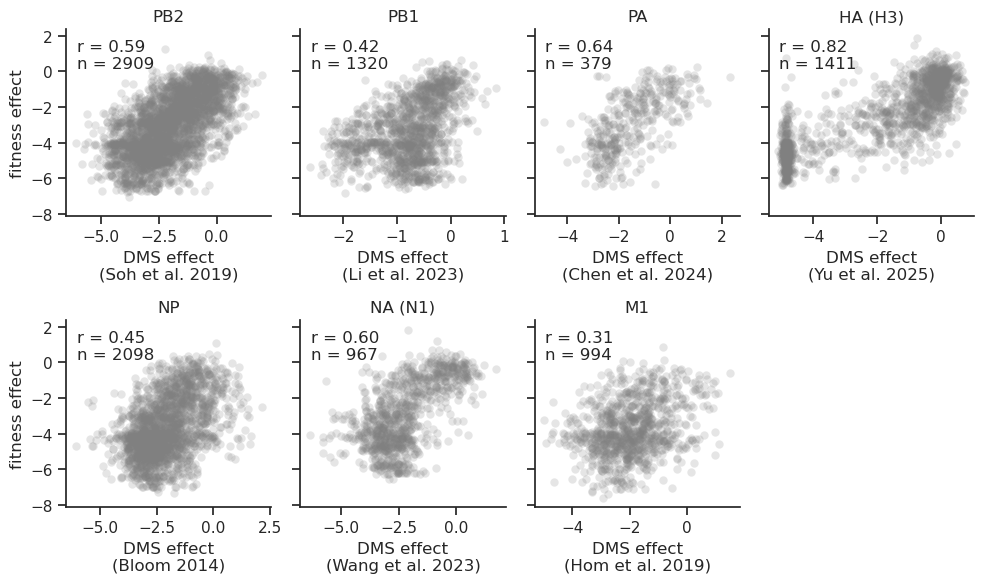

Resized to 1650x982 px (5.5x3.3 in at 300 DPI) -> ../results/figures/ms_figures/fitness_vs_dms.png


In [18]:
datasets = [
    ('PB2', pb2_dms_data),
    ('PB1', pb1_dms_data),
    ('PA', pa_dms_data),
    ('HA (H3)',  ha_dms_data),
    ('NP',  np_dms_data),
    ('NA (N1)',  na_dms_data),
    ('M1',  m1_dms_data),
]
author_year = {
    'HA (H3)' : 'Yu et al. 2025',
    'NP' : 'Bloom 2014',
    'M1' : 'Hom et al. 2019',
    'PB1' : 'Li et al. 2023',
    'PA' : 'Chen et al. 2024',
    'PB2' : 'Soh et al. 2019',
    'NA (N1)' : 'Wang et al. 2023',
}

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(10, 6), sharey=True)
axs = axs.flatten()

fitness_lod = np.log(0.5/(count_threshold_dms_comparison+0.5))
for ax, (label, df) in zip(axs, datasets):
    r = df['dms_effect'].corr(df['delta_fitness'])
    n = len(df)
    sns.scatterplot(
        x='dms_effect', y='delta_fitness', data=df,
        color='gray', alpha=0.2, linewidth=0, ax=ax
    )
    ax.annotate(f'r = {r:.2f}\nn = {n}', xy=(0.05, 0.95), xycoords='axes fraction', va='top')
    ax.set(
        title=label, xlabel=f'DMS effect\n({author_year[label]})',
        ylabel='fitness effect'
    )
    sns.despine(ax=ax)

# Hide the unused 8th subplot (previously held NEP).
axs[7].axis('off')

plt.tight_layout()
plt.savefig('../results/figures/fitness_vs_dms.png', dpi=300, bbox_inches='tight')
plt.show()

# Resize PNG to a 5-inch target width and write a manuscript-ready copy under
# results/figures/ms_figures/, matching compose_figures.ipynb.
from PIL import Image

dpi = 300
target_width_in = 5.5
src_png = '../results/figures/fitness_vs_dms.png'
out_dir = '../results/figures/ms_figures'
os.makedirs(out_dir, exist_ok=True)
out_png = f'{out_dir}/fitness_vs_dms.png'

img = Image.open(src_png)
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
img_resized.save(out_png, dpi=(dpi, dpi))
print(f'Resized to {new_width_px}x{new_height_px} px '
      f'({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI) -> {out_png}')

## Compare fitness effects between subsets

Four scatter plots: the random split-half pair (noise-floor reference) followed by the three pairwise geographic comparisons. Synonymous, nonsynonymous, and nonsense AA mutations are all included. The split_a/split_b panel is restricted to mutations that pass the whole-tree `fitness_df` count cutoff (`actual_count >= 10` or `expected_count >= 10`), and we assert that every such mutation is present in both splits. Each geographic panel applies the count cutoff independently to each region (≥10 actual or expected counts in both regions of the pair), without reference to the whole-tree filter.

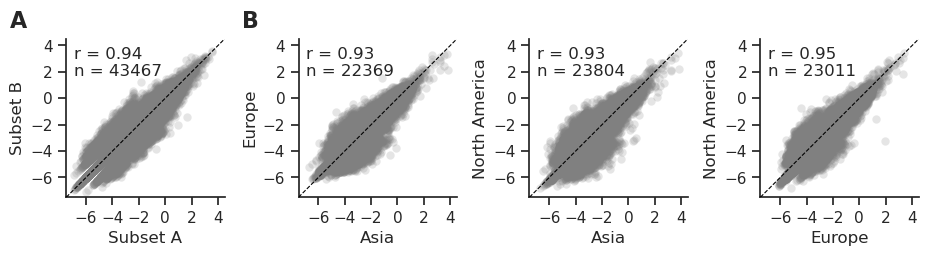

Resized to 1500x411 px (5.0x1.4 in at 300 DPI) -> ../results/figures/ms_figures/fitness_subsets_summary.png


In [19]:
# Subset fitness-effect summary plot.
# Panel A is the random split-half noise floor; panel B groups the three
# pairwise geographic comparisons. width_ratios=[1, 3] so every scatter
# (the one in A and the three in B) is allocated the same horizontal
# width; ax.set_aspect('equal') then forces each scatter to be square.
import matplotlib.gridspec as gridspec

subset_fitness_df = pd.read_csv(
    '../results/subset_aa_fitness_effects.csv', keep_default_na=False
)

counts_cutoff = 10
id_cols = ['subtype', 'segment', 'gene', 'codon_site', 'wt_aa', 'mut_aa']

# Universe for the split_a/split_b panel: mutations passing the whole-tree
# count cutoff in fitness_df. This makes the split-half noise floor directly
# comparable to the global fitness_df cohort. fitness_df is already filtered
# to host == 'all' upstream.
fitness_pass_keys = fitness_df[
    (fitness_df['actual_count'] >= counts_cutoff) |
    (fitness_df['expected_count'] >= counts_cutoff)
].set_index(id_cols).index


def merge_subset_pair(df, a, b, filter_mode):
    """Inner-join two subsets on id_cols and apply the requested filter.

    filter_mode='whole_tree': keep mutations whose key passes the whole-tree
        fitness_df cutoff. Asserts every such key is present in the merge.
    filter_mode='per_subset': keep mutations meeting the count cutoff in
        each of the two subsets independently.
    """
    cols = ['delta_fitness', 'actual_count', 'expected_count']
    da = df[df['subset'] == a].set_index(id_cols)[cols]
    db = df[df['subset'] == b].set_index(id_cols)[cols]
    merged = da.join(db, lsuffix=f'_{a}', rsuffix=f'_{b}', how='inner').dropna()
    if filter_mode == 'whole_tree':
        missing = fitness_pass_keys.difference(merged.index)
        assert len(missing) == 0, (
            f'{len(missing)} mutations passing the whole-tree fitness_df cutoff '
            f'are missing from the {a}/{b} subset merge'
        )
        return merged.loc[merged.index.intersection(fitness_pass_keys)].reset_index()
    elif filter_mode == 'per_subset':
        merged = merged.reset_index()
        keep = (
            ((merged[f'actual_count_{a}'] >= counts_cutoff) | (merged[f'expected_count_{a}'] >= counts_cutoff)) &
            ((merged[f'actual_count_{b}'] >= counts_cutoff) | (merged[f'expected_count_{b}'] >= counts_cutoff))
        )
        return merged[keep]
    else:
        raise ValueError(f'unknown filter_mode: {filter_mode}')


def pretty(s):
    return s.replace('split', 'subset').replace('_', ' ').title()


subset_pairs = [
    ('split_a', 'split_b', 'whole_tree'),
    ('asia', 'europe', 'per_subset'),
    ('asia', 'north_america', 'per_subset'),
    ('europe', 'north_america', 'per_subset'),
]

fig = plt.figure(figsize=(11, 3))
# Nested gridspec so the A-B gap and the within-B gap can be tuned
# independently. Each scatter column is 1.2 wide (a 20% bump). The
# B-region's outer width is sized to fit the three 1.2-wide axes plus the
# within-B gaps, so every scatter ends up exactly the same width.
b_axis_w = 1.2
within_b_gap = 0.55
b_region_w = 3 * b_axis_w + 2 * within_b_gap
ab_gap = 0.56  # ~50% of the previous A-B gap
outer_avg_w = (b_axis_w + b_region_w) / 2
outer_gs = fig.add_gridspec(
    1, 2, width_ratios=[b_axis_w, b_region_w], wspace=ab_gap / outer_avg_w
)
inner_gs_b = outer_gs[1].subgridspec(1, 3, wspace=within_b_gap / b_axis_w)
axs = [
    fig.add_subplot(outer_gs[0]),
    fig.add_subplot(inner_gs_b[0]),
    fig.add_subplot(inner_gs_b[1]),
    fig.add_subplot(inner_gs_b[2]),
]

ticks = np.arange(-6, 5, 2)  # [-6, -4, -2, 0, 2, 4]
lim = (-7.5, 4.5)

for ax, (a, b, filter_mode) in zip(axs, subset_pairs):
    merged = merge_subset_pair(subset_fitness_df, a, b, filter_mode)
    r = merged[f'delta_fitness_{a}'].corr(merged[f'delta_fitness_{b}'])
    n = len(merged)
    sns.scatterplot(
        x=f'delta_fitness_{a}', y=f'delta_fitness_{b}', data=merged,
        color='gray', alpha=0.2, linewidth=0, ax=ax,
    )
    ax.annotate(
        f'r = {r:.2f}\nn = {n}',
        xy=(0.05, 0.95), xycoords='axes fraction', va='top',
    )
    ax.set(
        xlabel=pretty(a), ylabel=pretty(b),
        xlim=lim, ylim=lim,
        xticks=ticks, yticks=ticks,
    )
    ax.axline((0, 0), slope=1, linestyle='--', color='black', linewidth=0.8, zorder=10)
    ax.set_aspect('equal')
    sns.despine(ax=ax)

# Bold panel labels positioned just above and to the left of panels A and B,
# matching the compose_figures.ipynb style.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
inv = fig.transFigure.inverted()
label_kwargs = dict(fontsize=16, fontweight='bold', va='bottom', ha='left')
tight_a = axs[0].get_tightbbox(renderer).transformed(inv)
tight_b = axs[1].get_tightbbox(renderer).transformed(inv)
pos_a = axs[0].get_position()
pos_b = axs[1].get_position()
fig.text(tight_a.x0, pos_a.y1 + 0.02, 'A', **label_kwargs)
fig.text(tight_b.x0, pos_b.y1 + 0.02, 'B', **label_kwargs)

plt.savefig('../results/figures/fitness_subsets_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Resize PNG to a 5-inch target width and write a manuscript-ready copy under
# results/figures/ms_figures/, matching the convention in compose_figures.ipynb.
from PIL import Image

dpi = 300
target_width_in = 5.0
src_png = '../results/figures/fitness_subsets_summary.png'
out_dir = '../results/figures/ms_figures'
os.makedirs(out_dir, exist_ok=True)
out_png = f'{out_dir}/fitness_subsets_summary.png'

img = Image.open(src_png)
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
img_resized.save(out_png, dpi=(dpi, dpi))
print(f'Resized to {new_width_px}x{new_height_px} px '
      f'({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI) -> {out_png}')


In [20]:
pb1_dms_data[
    (pb1_dms_data['delta_fitness'] < -4) &
    (pb1_dms_data['dms_effect'] > -1)
][['codon_site', 'wt_aa', 'mut_aa', 'dms_effect', 'delta_fitness']]

,codon_site,wt_aa,mut_aa,dms_effect,delta_fitness
0,1,M,I,-0.859333,-6.187741
5,4,N,D,0.060052,-5.051623
8,5,P,L,-0.664120,-4.085011
24,15,Q,R,-0.669634,-5.050859
27,17,A,T,-0.520483,-4.881385
...,...,...,...,...,...
1257,725,D,G,-0.419209,-4.235222
1263,727,R,L,-0.763014,-4.121132
1276,732,S,P,-0.634946,-5.051064
1305,747,C,Y,-0.559514,-6.207802


## Smoothed fitness effects across the genome

A line-plot analogue of the synonymous-only scatter above: average fitness effect of each mutation class in a 25-nt sliding window, plotted across each segment. Colors follow `mut_class_colors`. Red shading marks known packaging-signal regions (as before). Gray shading on MP and NS marks nt regions where two ORFs overlap (M1/M2 and NS1/NEP).

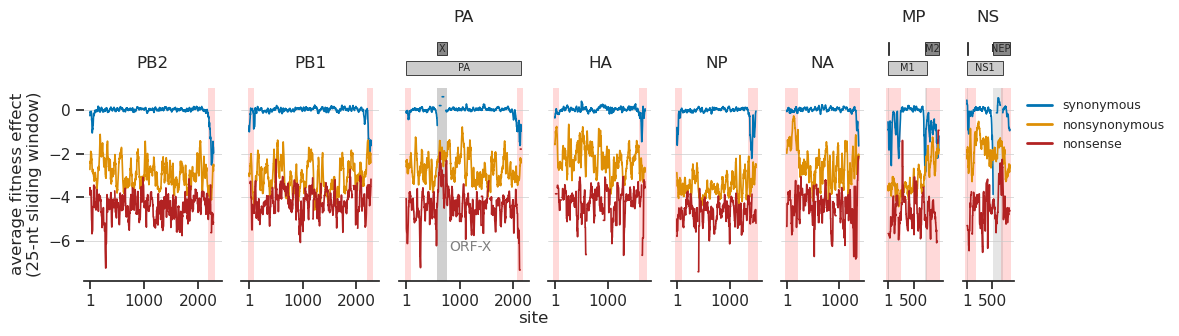

Resized to 1950x556 px (6.5x1.9 in at 300 DPI) -> ../results/figures/ms_figures/fitness_effect_smoothed.png


In [21]:
# Per-codon, per-mut_class average fitness effect, then a 25-nt sliding-window
# smoothing in nucleotide coordinates. Codon -> nt mapping comes from
# coding_sites.csv (handles overlapping/spliced ORFs correctly: each nt site
# inherits the average of its gene-specific codon, and overlap nt average
# across genes).
count_threshold = 10

fit_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
for col in ['gene', 'codon_site', 'wt_aa', 'mut_aa']:
    fit_data[col] = fit_data[col].astype(str).str.split(';')
fit_data = fit_data.explode(['gene', 'codon_site', 'wt_aa', 'mut_aa'])
fit_data['codon_site'] = fit_data['codon_site'].astype(int)

codon_avg = (
    fit_data
    .groupby(['segment', 'subtype', 'gene', 'codon_site', 'mut_class'], as_index=False)
    ['delta_fitness'].mean()
)

segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = [cds_lengths[seg] for seg in segments]
window_nt = 25
mut_class_order = ['synonymous', 'nonsynonymous', 'nonsense']

fig, axs = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 2.5],
    gridspec_kw={'width_ratios': width_ratios},
)
for i, segment in enumerate(segments):
    ax = axs[i]
    cds_len = cds_lengths[segment]
    seg_subtype = segment_subtypes[segment]

    # Per-nt mapping (gene, codon_site) for this segment+subtype
    cs = pd.read_csv(
        f'../results/{segment}/{seg_subtype}/coding_sites.csv',
        keep_default_na=False,
    )
    cs = cs.assign(
        gene=cs['gene'].astype(str).str.split(';'),
        codon_site=cs['codon_site'].astype(str).str.split(';'),
    ).explode(['gene', 'codon_site'])
    cs['codon_site'] = cs['codon_site'].astype(int)

    seg_codon_avg = codon_avg[
        (codon_avg['segment'] == segment) &
        (codon_avg['subtype'] == seg_subtype)
    ]

    for mut_class in mut_class_order:
        mc = seg_codon_avg.loc[
            seg_codon_avg['mut_class'] == mut_class,
            ['gene', 'codon_site', 'delta_fitness'],
        ]
        merged = cs.merge(mc, on=['gene', 'codon_site'], how='left')
        # Average across overlapping ORFs at each nt site, then smooth
        per_nt = (
            merged.groupby('site')['delta_fitness'].mean()
            .reindex(range(1, cds_len + 1))
        )
        smoothed = per_nt.rolling(window=window_nt, center=True, min_periods=1).mean()
        ax.plot(
            smoothed.index, smoothed.values,
            color=mut_class_colors[mut_class], lw=1.2, label=mut_class,
        )

    # Packaging-signal regions (red) — same buffer/style as fitness_effect_syn.png
    for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
        if row['nt'] == 0:
            continue
        if row['end'] == '3prime_vRNA':
            x_start, x_end = 1, row['nt']
        else:
            x_start, x_end = cds_len - row['nt'] + 1, cds_len
        buffer = 30
        x_start -= buffer
        x_end += buffer
        ax.axvspan(x_start, x_end, alpha=0.15, color='red', zorder=0, lw=0)

    # PA ORF-X annotation (matches fitness_effect_syn.png)
    if segment == 'PA':
        ax.axvspan(572, 760, alpha=0.2, color='gray', zorder=0, lw=0)
        ax.text(0.55, 0.21, 'ORF-X', transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

    # Shade nt regions where two ORFs overlap, then draw the ORF exon tracks above.
    shade_orf_overlap_regions(ax, segment)
    draw_orf_tracks_above(ax, segment)

    ax.grid(axis='y', which='both', lw=0.5)
    title_y = 1.30 if segment in orf_tracks else 1.06
    ax.set_title(segment, y=title_y)
    ax.set(xlabel='')
    if i > 0:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    if cds_len < 1000:
        ax.set_xticks([1, 500])
    elif cds_len < 2000:
        ax.set_xticks([1, 1000])
    else:
        ax.set_xticks([1, 1000, 2000])
    sns.despine(left=True, ax=ax)

# One legend on the rightmost panel (one entry per mut_class)
handles = [
    matplotlib.lines.Line2D([0], [0], color=mut_class_colors[m], lw=2, label=m)
    for m in mut_class_order
]
axs[-1].legend(
    handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left',
    fontsize=9, frameon=False,
)

axs[0].set(ylabel=f'average fitness effect\n({window_nt}-nt sliding window)')
fig.text(0.5, -0.06, 'site', ha='center')
plt.savefig('../results/figures/fitness_effect_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()

# Resize PNG to a 6.5-inch target width and write a manuscript-ready copy under
# results/figures/ms_figures/, matching the convention in compose_figures.ipynb.
from PIL import Image

dpi = 300
target_width_in = 6.5
src_png = '../results/figures/fitness_effect_smoothed.png'
out_dir = '../results/figures/ms_figures'
os.makedirs(out_dir, exist_ok=True)
out_png = f'{out_dir}/fitness_effect_smoothed.png'

img = Image.open(src_png)
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
img_resized.save(out_png, dpi=(dpi, dpi))
print(f'Resized to {new_width_px}x{new_height_px} px '
      f'({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI) -> {out_png}')
